#### Comparitive Study on Sentiment Analysis of Political Speeches: Analyzing the Prime Minister's and Rahul Gandhi 

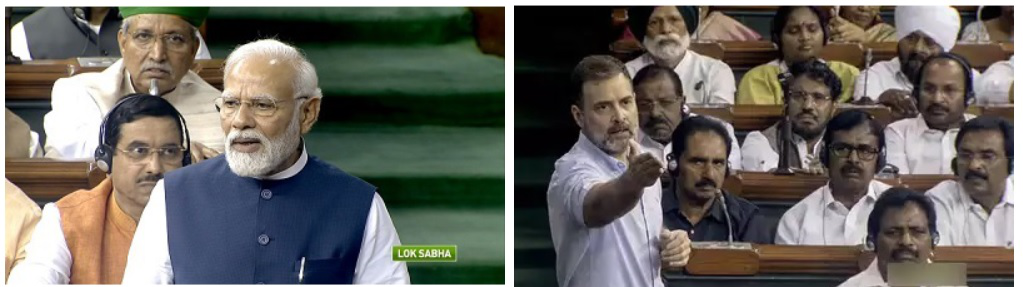

In [1]:
from IPython.display import display
from PIL import Image

image1 = Image.open("Modi Rahul.jpg")

display(image1)

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
file_path = "Rahul Gandhi Speech.txt"

In [5]:
with open(file_path, "r", encoding="utf-8") as file:
    speech_text = file.read()
    

In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [7]:
#nltk.download('vader_lexicon')

In [8]:

speech_text_cleaned = re.sub(r'[^\w\s]', '', speech_text)

speech_text_cleaned = speech_text_cleaned.lower()

words = word_tokenize(speech_text_cleaned)

stop_words = set(stopwords.words("english"))

words_filtered = [word for word in words if word not in stop_words]


In [9]:
words_filtered[:10]

['joking',
 'parliament',
 'manipur',
 'fire',
 'rahul',
 'gandhi',
 'slams',
 'pm',
 'modi',
 'prime']

In [10]:

lemmatizer = WordNetLemmatizer()
words_lemmatized = [lemmatizer.lemmatize(word) for word in words_filtered]
words_lemmatized[:10]


['joking',
 'parliament',
 'manipur',
 'fire',
 'rahul',
 'gandhi',
 'slam',
 'pm',
 'modi',
 'prime']

In [11]:

sia = SentimentIntensityAnalyzer()

sentiment_scores = [sia.polarity_scores(word)["compound"] for word in words_lemmatized]

average_sentiment = sum(sentiment_scores) / len(sentiment_scores)


In [12]:

print('The average sentiment is:', average_sentiment)

The average sentiment is: -0.02273167259786477


In [13]:

positive_words = [word for i, word in enumerate(words_filtered) if sentiment_scores[i] > 0.1]

negative_words = [word for i, word in enumerate(words_filtered) if sentiment_scores[i] < -0.1]

neutral_words = [word for i, word in enumerate(words_filtered) if sentiment_scores[i] >= -0.1 and sentiment_scores[i] <= 0.1]


In [14]:
print('The positive words are:', positive_words)

The positive words are: ['joking', 'hands', 'laughing', 'joking', 'laughing', 'peacefully', 'harmoniously', 'affection', 'hands', 'faith', 'party', 'justice']


In [15]:
print('The negative words are:', negative_words)

The negative words are: ['fire', 'slams', 'stop', 'violence', 'stop', 'forgotten', 'fire', 'fire', 'molested', 'raped', 'murdered', 'murdered', 'insult', 'wrong', 'killed', 'refuses', 'stop', 'fire', 'stop', 'stop', 'violence', 'stop', 'petty', 'tragic', 'sad', 'ridiculous', 'misunderstanding', 'murdered']


In [16]:
print('The neutral words are:', neutral_words)

The neutral words are: ['parliament', 'manipur', 'rahul', 'gandhi', 'pm', 'modi', 'prime', 'minister', 'wants', 'manipur', 'burn', 'allows', 'burn', 'mr', 'gandhi', 'alleged', 'press', 'conference', 'aicc', 'headquarters', 'delhi', 'asserted', 'modi', 'government', 'wanted', 'tools', 'government', 'immediately', 'watched', 'prime', 'minister', 'yesterday', 'speaking', 'two', 'hours', 'raising', 'slogans', 'parliament', 'prime', 'minister', 'would', 'say', 'one', 'line', 'bjp', 'leaders', 'would', 'shout', 'another', 'slogan', 'prime', 'minister', 'seems', 'state', 'manipur', 'four', 'months', 'women', 'children', 'dying', 'women', 'prime', 'minister', 'india', 'sitting', 'middle', 'parliament', 'rahul', 'gandhi', 'congress', 'opposition', 'india', 'country', 'state', 'decimated', 'exist', 'anymore', 'happened', 'politics', 'bjp', 'divide', 'rule', 'burn', 'mr', 'gandhi', 'said', 'said', 'idea', 'india', 'bjp', 'manipur', 'speaking', 'metaphorically', 'speaking', 'literally', 'former', 

In [17]:
word_freq_positive = nltk.FreqDist(positive_words)
word_freq_negative = nltk.FreqDist(negative_words)
word_freq_neutral = nltk.FreqDist(neutral_words)

In [18]:
print('The positive words frequency is:', word_freq_positive)

The positive words frequency is: <FreqDist with 9 samples and 12 outcomes>


In [19]:
print('The negative words frequency is:', word_freq_negative)

The negative words frequency is: <FreqDist with 17 samples and 28 outcomes>


In [20]:
print('The neutral words frequency is:', word_freq_neutral)

The neutral words frequency is: <FreqDist with 125 samples and 241 outcomes>


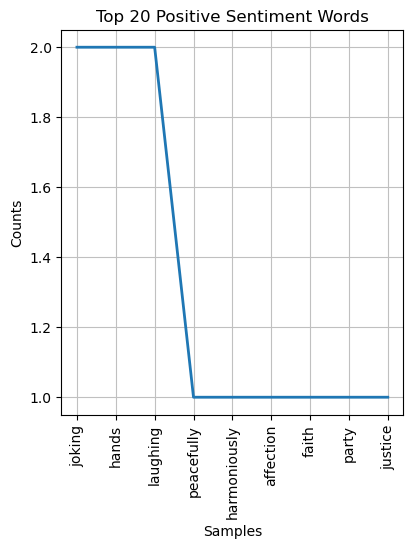

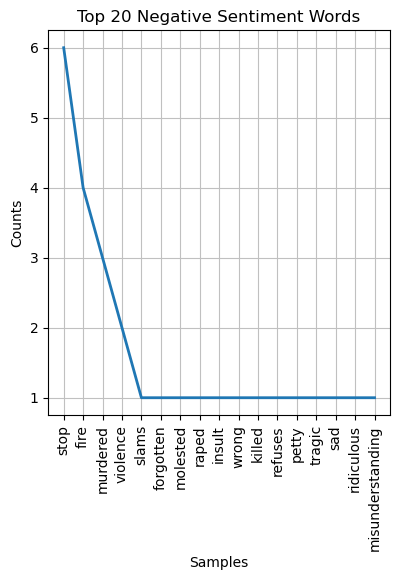

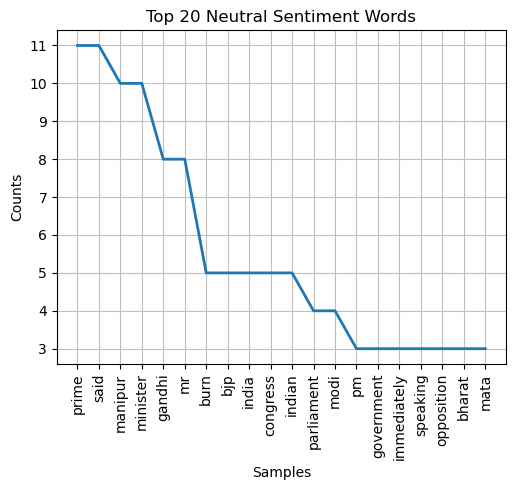

In [21]:
plt.figure(figsize=(15, 5))

plt.subplot(131)
word_freq_positive.plot(20, title="Top 20 Positive Sentiment Words")

plt.figure(figsize=(15, 5))
plt.subplot(132)
word_freq_negative.plot(20, title="Top 20 Negative Sentiment Words")

plt.figure(figsize=(15, 5))
plt.subplot(133)
word_freq_neutral.plot(20, title="Top 20 Neutral Sentiment Words")

plt.tight_layout()
plt.show()

In [22]:
df_positive = pd.DataFrame(word_freq_positive.most_common(20), columns=['Word', 'Frequency'])
df_negative = pd.DataFrame(word_freq_negative.most_common(20), columns=['Word', 'Frequency'])
df_neutral = pd.DataFrame(word_freq_neutral.most_common(20), columns=['Word', 'Frequency'])

In [23]:
fig_positive = px.bar(df_positive, x='Word', y='Frequency', title="Top 20 Positive Sentiment Words")
fig_negative = px.bar(df_negative, x='Word', y='Frequency', title="Top 20 Negative Sentiment Words")
fig_neutral = px.bar(df_neutral, x='Word', y='Frequency', title="Top 20 Neutral Sentiment Words")

fig_positive.show()
fig_negative.show()
fig_neutral.show()

In [24]:
wordcloud_positive = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq_positive)
wordcloud_negative = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq_negative)
wordcloud_neutral = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq_neutral)

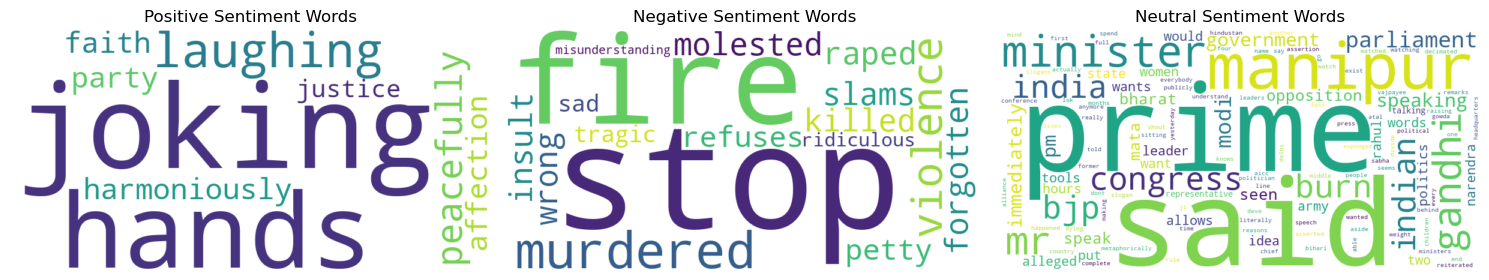

In [25]:
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Sentiment Words")

plt.subplot(132)
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Sentiment Words")

plt.subplot(133)
plt.imshow(wordcloud_neutral, interpolation="bilinear")
plt.axis("off")
plt.title("Neutral Sentiment Words")

plt.tight_layout()
plt.show()

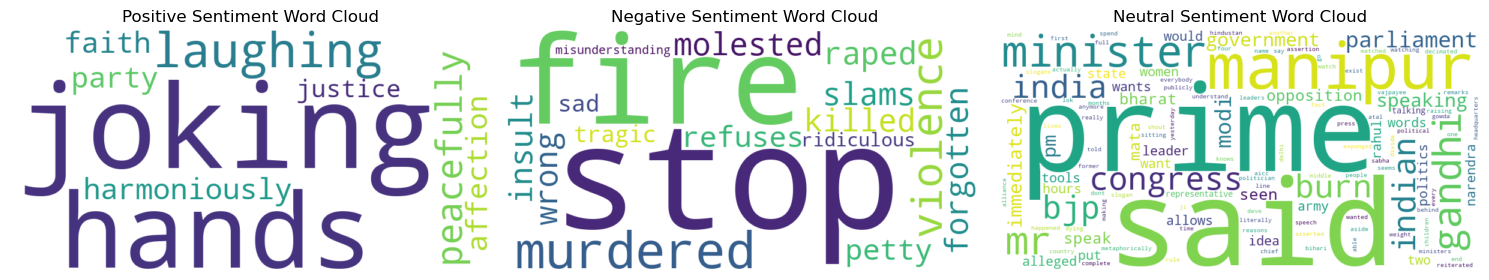

In [26]:
plt.figure(figsize=(15, 10))

plt.subplot(131)
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.title("Positive Sentiment Word Cloud")
plt.axis("off")

plt.subplot(132)
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.title("Negative Sentiment Word Cloud")
plt.axis("off")

plt.subplot(133)
plt.imshow(wordcloud_neutral, interpolation="bilinear")
plt.title("Neutral Sentiment Word Cloud")
plt.axis("off")

plt.tight_layout()
plt.show()

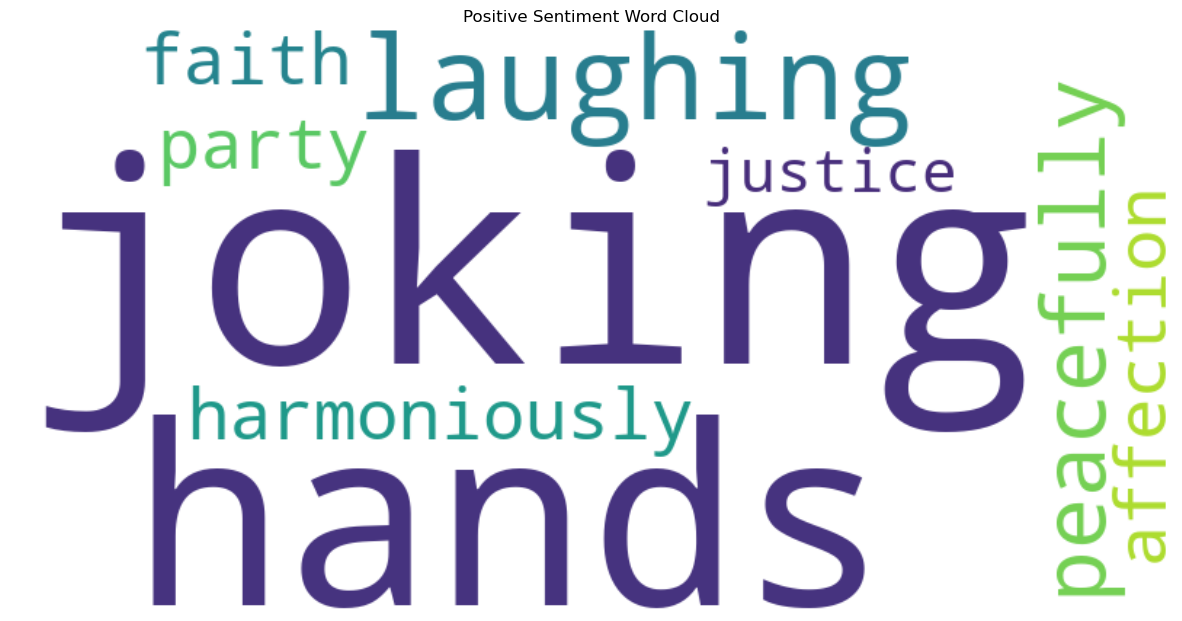

In [27]:
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.title("Positive Sentiment Word Cloud")
plt.axis("off")
plt.show()

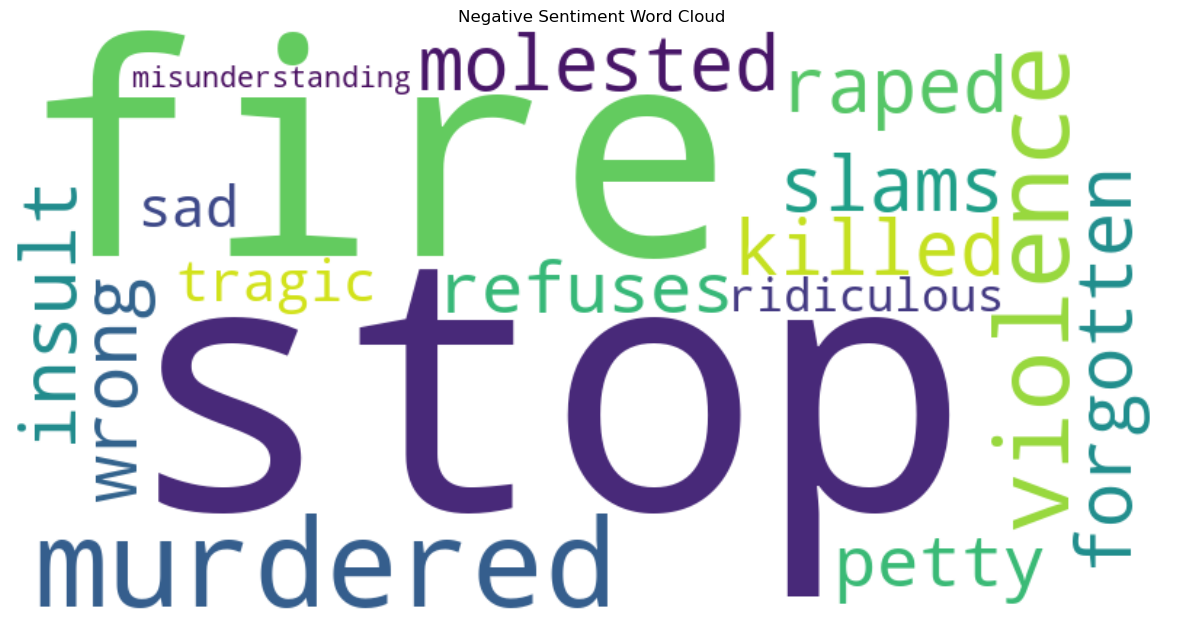

In [28]:
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.title("Negative Sentiment Word Cloud")
plt.axis("off")
plt.show()

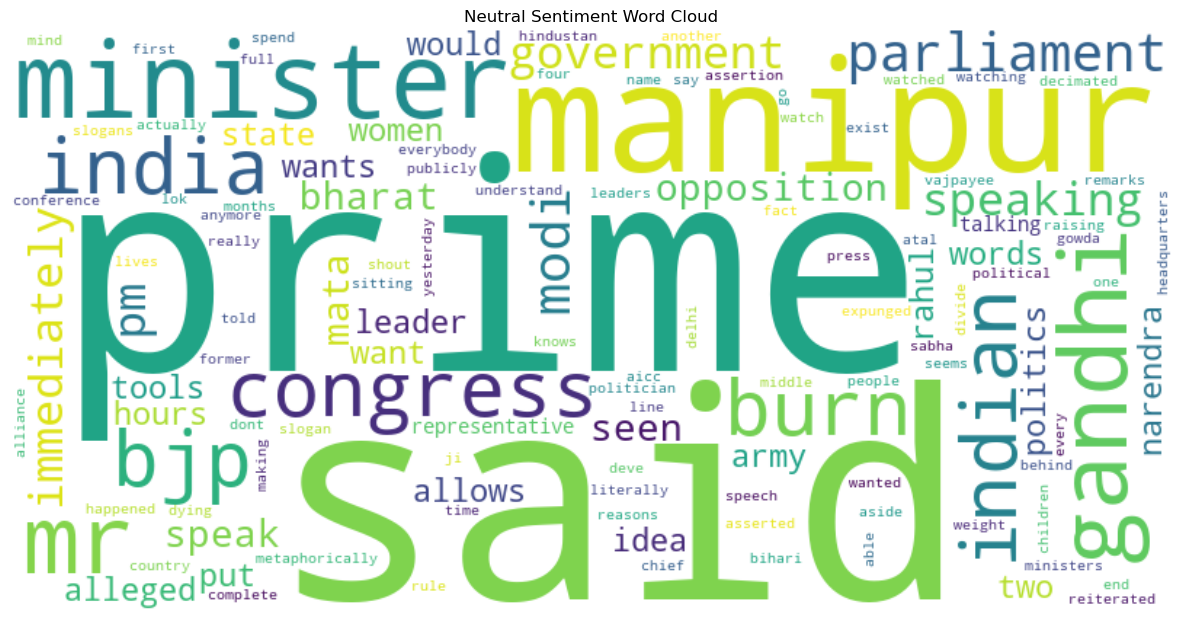

In [29]:
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud_neutral, interpolation="bilinear")
plt.title("Neutral Sentiment Word Cloud")
plt.axis("off")
plt.show()

In [30]:
word_freq = nltk.FreqDist(words_lemmatized)
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq)

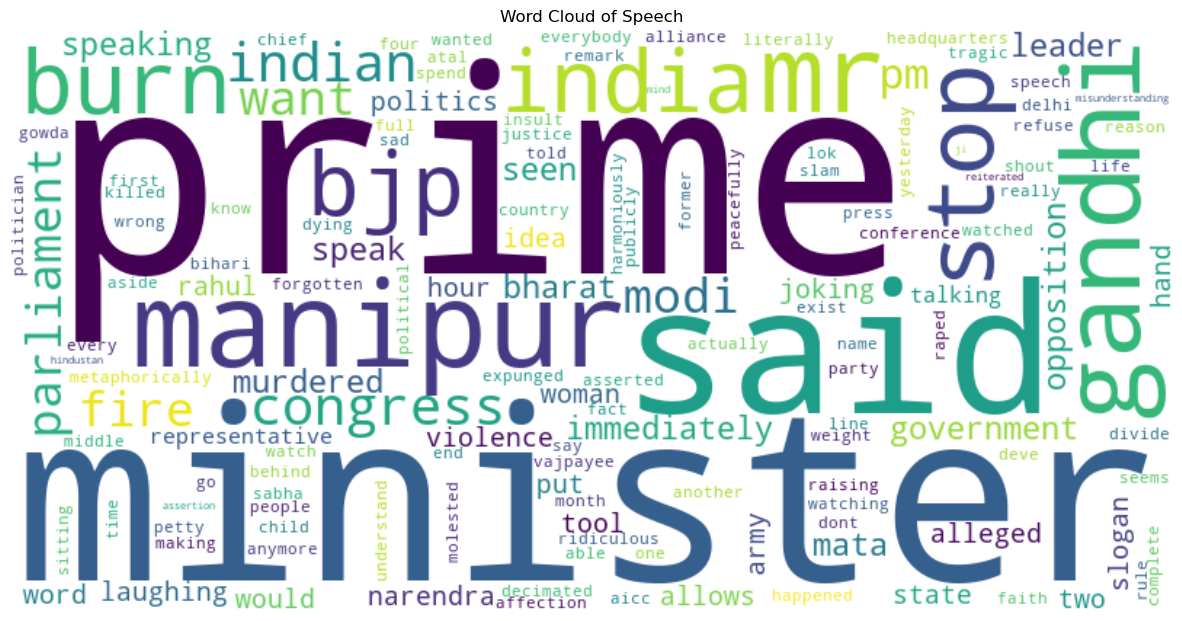

In [31]:
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Speech")
plt.show()

In [32]:
total_words = len(words_filtered)
positive_percentage = (len(positive_words) / total_words) * 100
negative_percentage = (len(negative_words) / total_words) * 100
neutral_percentage = (len(neutral_words) / total_words) * 100

print("Positive Sentiment Percentage:", positive_percentage)
print("Negative Sentiment Percentage:", negative_percentage)
print("Neutral Sentiment Percentage:", neutral_percentage)

Positive Sentiment Percentage: 4.270462633451958
Negative Sentiment Percentage: 9.9644128113879
Neutral Sentiment Percentage: 85.76512455516014


In [33]:
data = {'Sentiment': ['Positive', 'Negative', 'Neutral'],
        'Percentage': [positive_percentage, negative_percentage, neutral_percentage]}

In [34]:
df_percentages = pd.DataFrame(data)

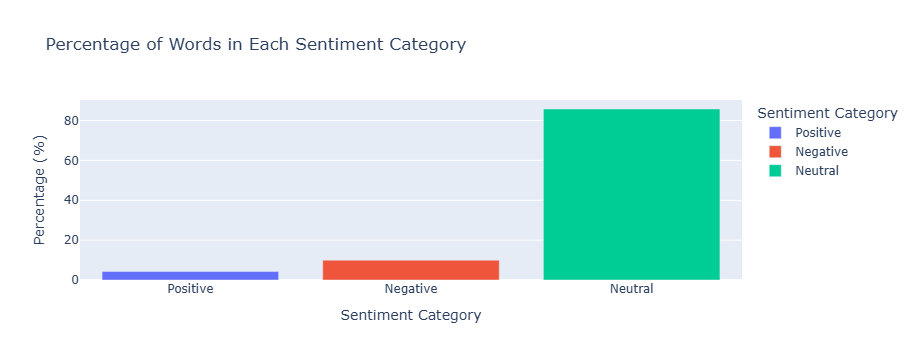

In [35]:
fig = px.bar(df_percentages, x='Sentiment', y='Percentage', color='Sentiment',
             labels={'Sentiment': 'Sentiment Category', 'Percentage': 'Percentage (%)'},
             title='Percentage of Words in Each Sentiment Category')
fig.show()